In [73]:
import torch
import torch.nn.functional as F

result_path = "release-1gpus-b8-s1-80k-camray-prope_A"
step = 30000

original_t = torch.load(f"../results/nvs_vae/{result_path}/visuals/gt.pt")
reconstructed_t = torch.load(f"../results/nvs_vae/{result_path}/visuals/outputs{step}.pt")

mse_t = (original_t - reconstructed_t).square()


/tmp/ipykernel_2334/1671482074.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  original_t = torch.load(f"../results/nvs_vae/{result_path}/visuals/gt.pt")
/tmp/ipykernel_

In [49]:
import matplotlib.pyplot as plt

def plot_latents(x,cmap="viridis"):

    x = x.detach().numpy()

    x = x.squeeze() 

    vmin = x.min().item()
    vmax = x.max().item()

    num_layers = x.shape[-1]
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))

    ims = []
    for i in range(num_layers):
        ax = axes[i // 4, i % 4]
        im = ax.imshow(x[:, :, i], cmap=cmap, vmin=vmin, vmax=vmax)
        ims.append(im)
        ax.set_title(f"Layer {i}")
        ax.axis("off")

    # ONE shared colorbar for all subplots
    fig.colorbar(ims[0], ax=axes, location='right', shrink=.5)

    plt.show()


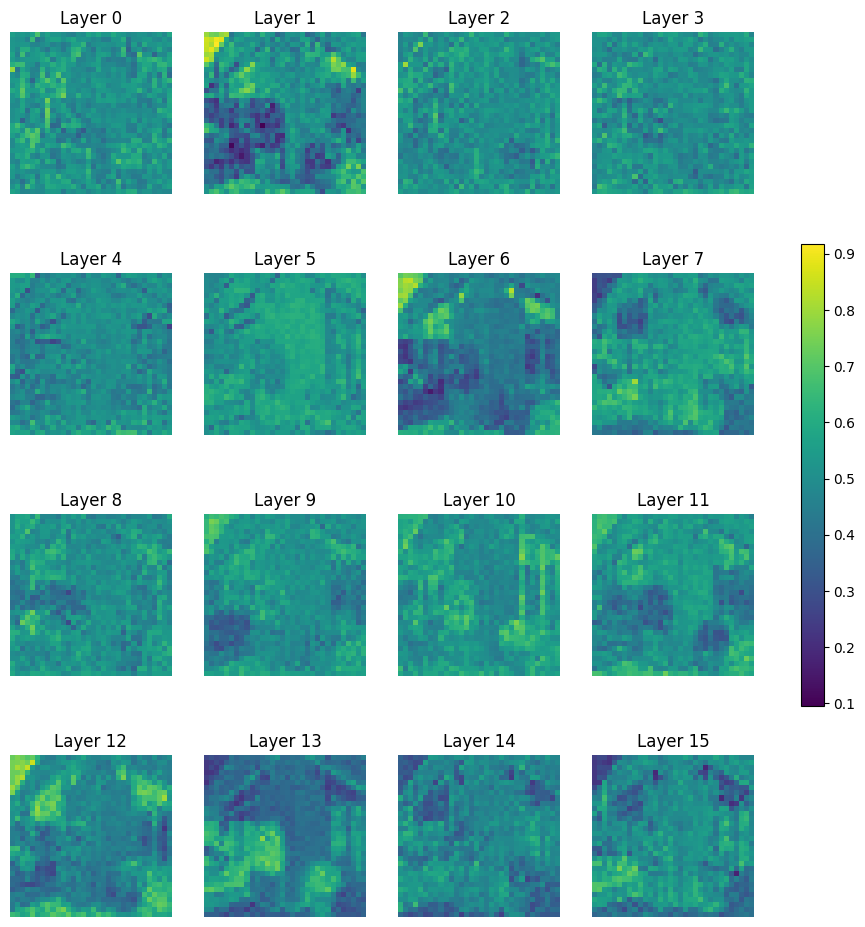

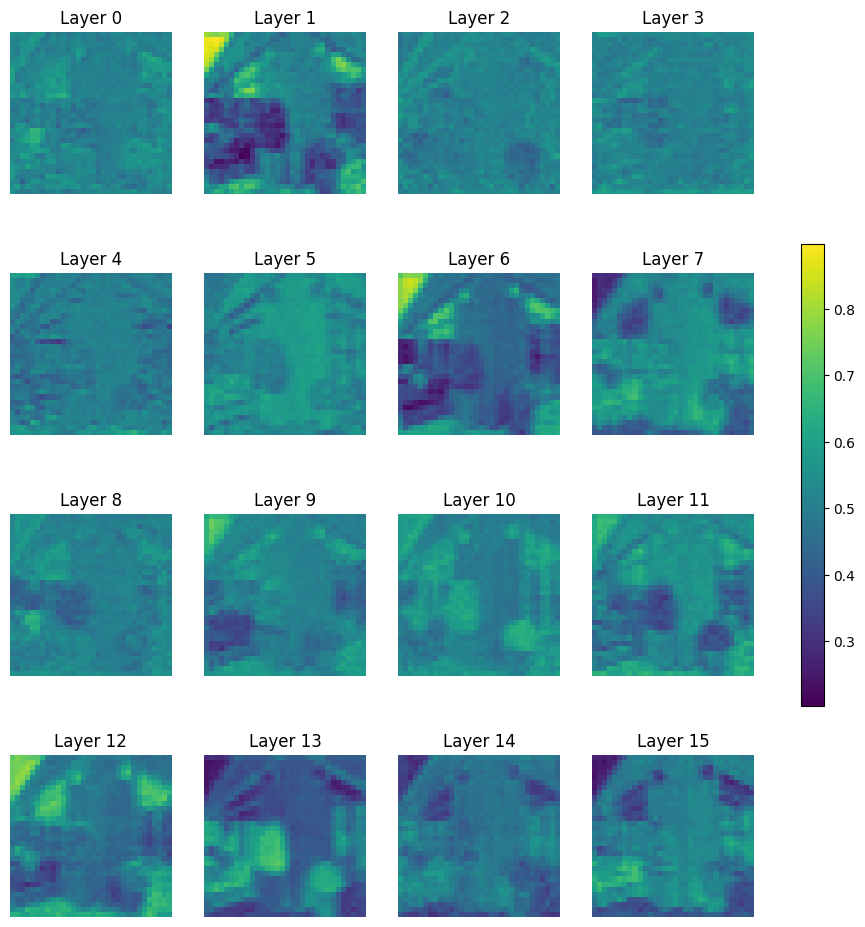

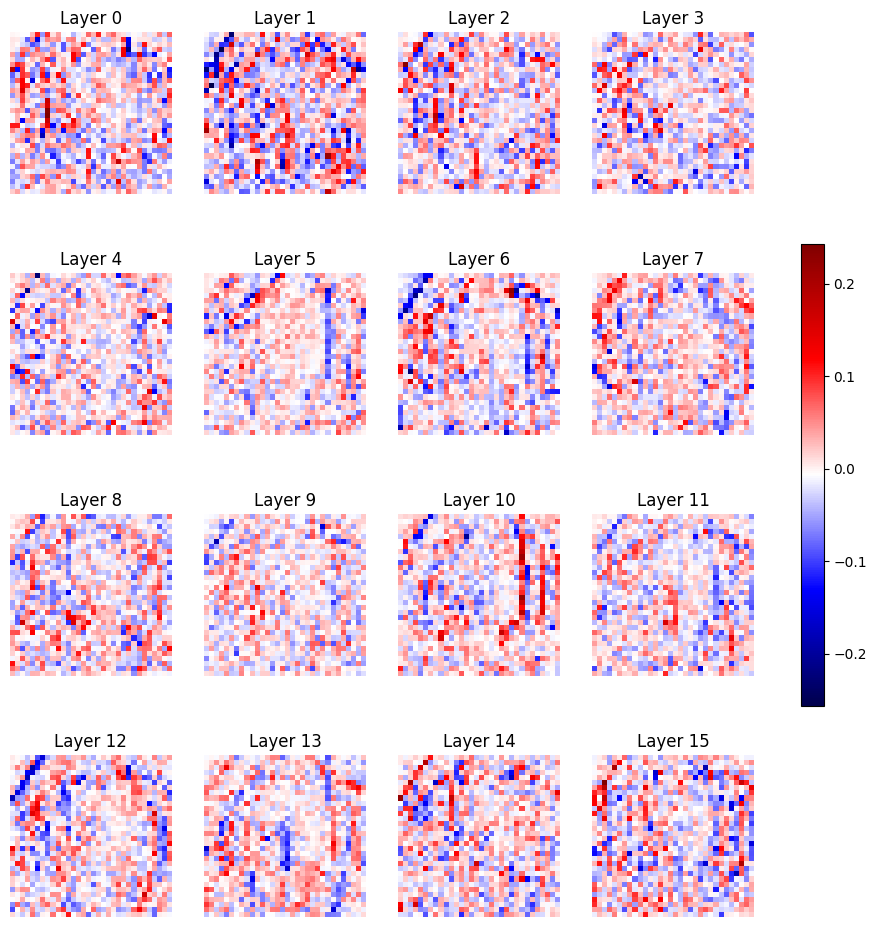

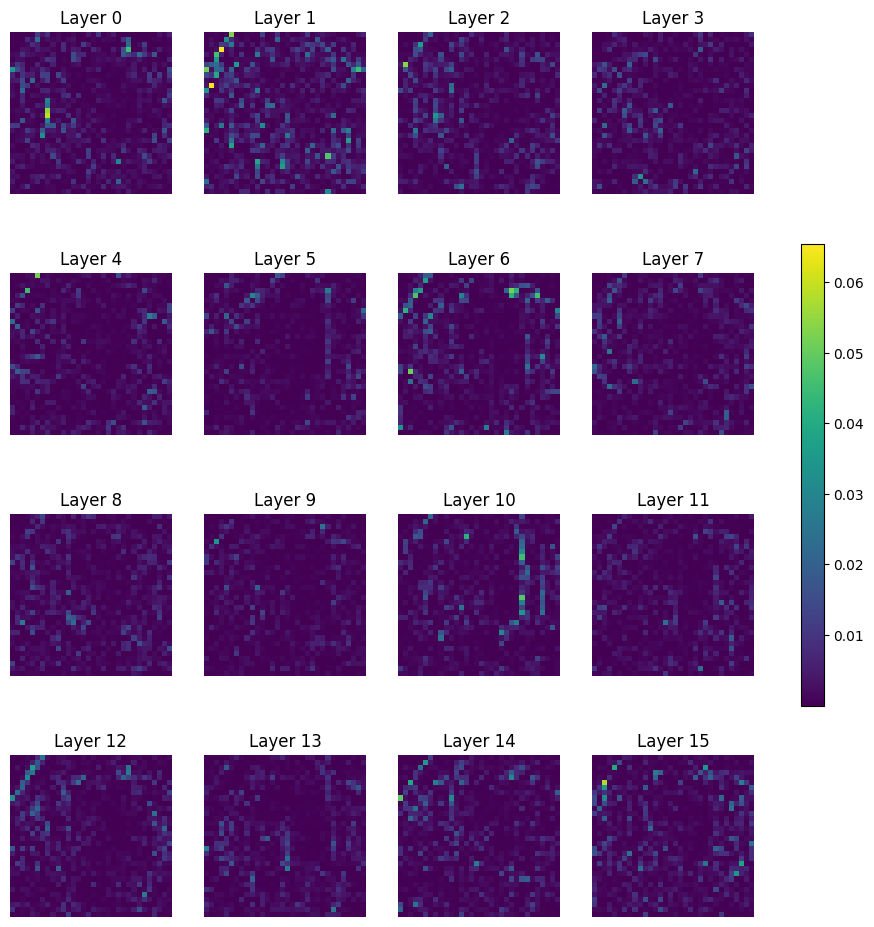

In [74]:
plot_latents(original_t)
plot_latents(reconstructed_t)
plot_latents(original_t-reconstructed_t, cmap="seismic")
plot_latents(mse_t)

In [48]:
original_t

tensor([[[[[0.5600, 0.8020, 0.4560,  ..., 0.2722, 0.3560, 0.2528],
           [0.5163, 0.7573, 0.5486,  ..., 0.3164, 0.3345, 0.2945],
           [0.5131, 0.7460, 0.5338,  ..., 0.3060, 0.3040, 0.2743],
           ...,
           [0.5074, 0.5006, 0.5337,  ..., 0.4008, 0.4876, 0.4975],
           [0.4897, 0.5998, 0.4667,  ..., 0.4530, 0.5026, 0.4929],
           [0.4854, 0.5014, 0.5393,  ..., 0.4047, 0.4983, 0.4859]],

          [[0.5218, 0.8657, 0.4660,  ..., 0.2373, 0.3315, 0.2271],
           [0.4655, 0.8974, 0.5112,  ..., 0.2433, 0.3452, 0.2675],
           [0.5031, 0.9306, 0.4970,  ..., 0.2459, 0.3124, 0.2488],
           ...,
           [0.4619, 0.5315, 0.5765,  ..., 0.4737, 0.4103, 0.5438],
           [0.5421, 0.5617, 0.4286,  ..., 0.3961, 0.4609, 0.5118],
           [0.4640, 0.5338, 0.5491,  ..., 0.4323, 0.4248, 0.5234]],

          [[0.5271, 0.8580, 0.4665,  ..., 0.2401, 0.3432, 0.2332],
           [0.5077, 0.8465, 0.5075,  ..., 0.2632, 0.3772, 0.2476],
           [0.5508, 0.8786

In [72]:
mse = F.mse_loss(reconstructed_t, original_t)
# mse = F.mse_loss(reconstructed_t.float(), original_t.float())
mse_sum = F.mse_loss(reconstructed_t, original_t, reduction="sum")

print(f"mse_avg: {mse}")
print(f"mse_sum: {mse_sum}")

mse_avg: 0.010977122001349926
mse_sum: 179.8491668701172
